In [1]:
import nasdaqdatalink

In [2]:
import pandas as pd

In [3]:
nasdaqdatalink.ApiConfig.api_key = ''

In [6]:
df = nasdaqdatalink.get_table(datatable_code="WIKI/PRICES",
                              ticker="TSLA",
                              paginate=True,
                              api_key= nasdaqdatalink.ApiConfig.api_key)
df.head()

,ticker,date,open,high,low,close,volume,ex-dividend,split_ratio,adj_open,adj_high,adj_low,adj_close,adj_volume
None,,,,,,,,,,,,,,
0,TSLA,2018-03-27,304.00,304.27,277.18,279.18,13696168.0,0.0,1.0,304.00,304.27,277.18,279.18,13696168.0
1,TSLA,2018-03-26,307.34,307.59,291.36,304.18,8324639.0,0.0,1.0,307.34,307.59,291.36,304.18,8324639.0
2,TSLA,2018-03-23,311.25,311.61,300.45,301.54,6600538.0,0.0,1.0,311.25,311.61,300.45,301.54,6600538.0
3,TSLA,2018-03-22,313.89,318.82,308.18,309.10,4914307.0,0.0,1.0,313.89,318.82,308.18,309.10,4914307.0
4,TSLA,2018-03-21,310.25,322.44,310.19,316.53,5927881.0,0.0,1.0,310.25,322.44,310.19,316.53,5927881.0


In [10]:
df.shape

(1949, 14)

In [13]:
df.tail()

,ticker,date,open,high,low,close,volume,ex-dividend,split_ratio,adj_open,adj_high,adj_low,adj_close,adj_volume
None,,,,,,,,,,,,,,
1944,TSLA,2010-07-06,20.00,20.0000,15.83,16.11,6866900.0,0.0,1.0,20.00,20.0000,15.83,16.11,6866900.0
1945,TSLA,2010-07-02,23.00,23.1000,18.71,19.20,5139800.0,0.0,1.0,23.00,23.1000,18.71,19.20,5139800.0
1946,TSLA,2010-07-01,25.00,25.9200,20.27,21.96,8218800.0,0.0,1.0,25.00,25.9200,20.27,21.96,8218800.0
1947,TSLA,2010-06-30,25.79,30.4192,23.30,23.83,17187100.0,0.0,1.0,25.79,30.4192,23.30,23.83,17187100.0
1948,TSLA,2010-06-29,19.00,25.0000,17.54,23.89,18766300.0,0.0,1.0,19.00,25.0000,17.54,23.89,18766300.0


In [16]:
import matplotlib

In [19]:
import matplotlib.pyplot as plt

In [21]:
df['date'] = pd.to_datetime(df['date'])

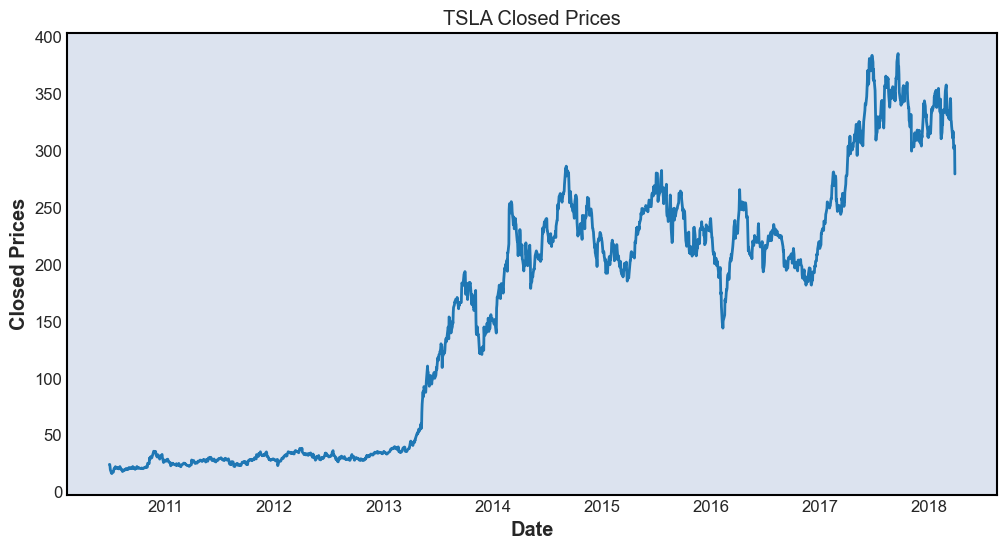

In [128]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(df['date'], df['close'])
plt.xlabel("Date")
plt.ylabel("Closed Prices")
plt.title("TSLA Closed Prices")
plt.grid(False)

Text(0.5, 1.0, 'TSLA Adj Prices')

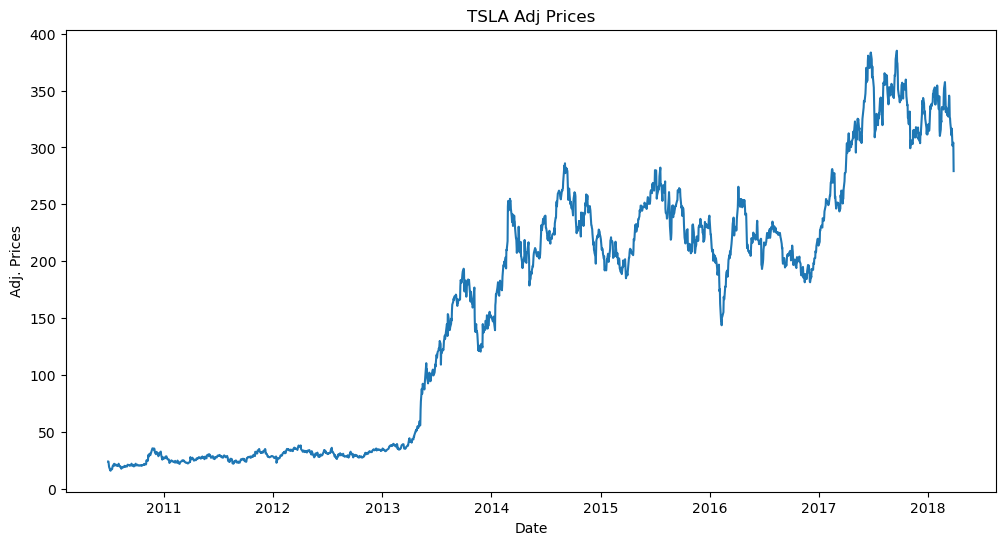

In [48]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(df['date'], df['adj_close'])
plt.xlabel("Date")
plt.ylabel("Adj. Prices")
plt.title("TSLA Adj Prices")

In [130]:
volumes = df['adj_volume']

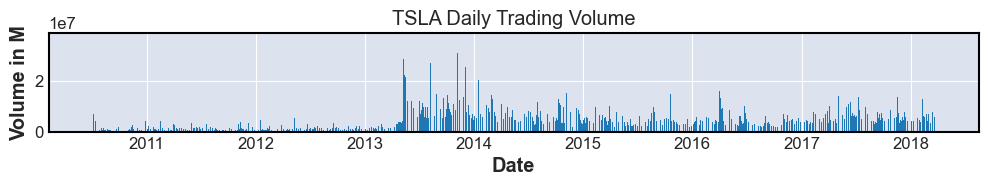

In [134]:
bottom = plt.subplot2grid((4, 4), (3,0), rowspan=4, colspan=6)
bottom.bar(df['date'], volumes)
plt.title('TSLA Daily Trading Volume')
plt.xlabel('Date')
plt.ylabel("Volume in M")
plt.gcf().set_size_inches(12, 8)
plt.subplots_adjust(hspace=0.75)

In [85]:
import numpy as np

In [86]:
import nasdaqdatalink

In [87]:
import mplfinance as mpf

In [91]:
df_candle = nasdaqdatalink.get_table(datatable_code='WIKI/PRICES',
                                     ticker='TSLA',
                                     date={'gte': '2017-12-01', 'lte': '2018-03-27'},
                                     qopts={'columns': ['date', 'open', 'high', 'low', 'close', 'volume']},
                                     api_key=nasdaqdatalink.ApiConfig.api_key)
df_candle.head()

,date,open,high,low,close,volume
None,,,,,,
0,2018-03-27,304.00,304.27,277.18,279.18,13696168.0
1,2018-03-26,307.34,307.59,291.36,304.18,8324639.0
2,2018-03-23,311.25,311.61,300.45,301.54,6600538.0
3,2018-03-22,313.89,318.82,308.18,309.10,4914307.0
4,2018-03-21,310.25,322.44,310.19,316.53,5927881.0


In [92]:
df_candle['date'] = pd.to_datetime(df_candle['date'])

In [94]:
df_candle = df_candle.sort_values('date')

In [95]:
df_candle = df_candle.set_index('date')

In [97]:
df_candle = df_candle.rename(columns={'open' : 'Open',
                                      'high' : 'High',
                                      'low' : "Low",
                                      'close' : "Close",
                                      'volume' : 'Volume'})

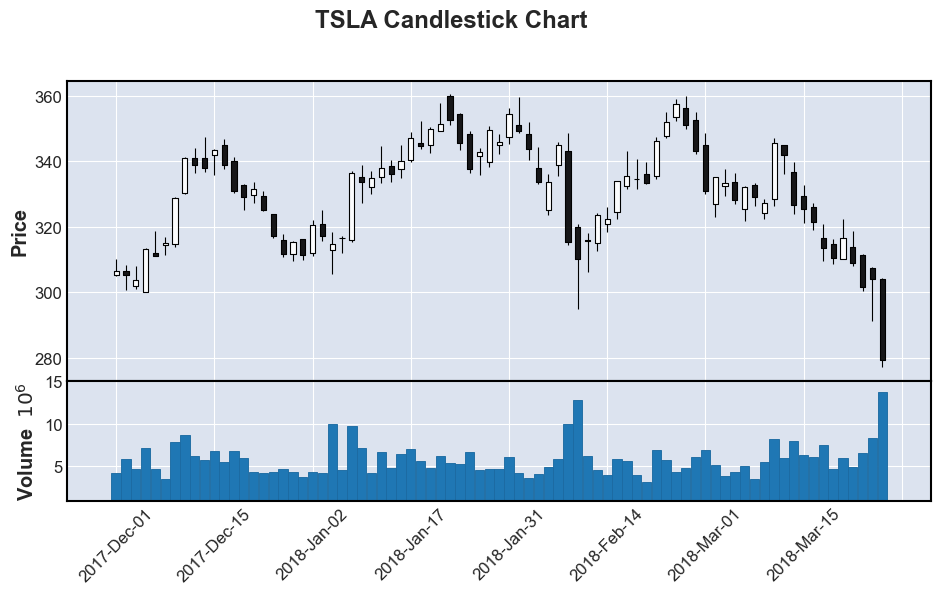

In [102]:
mpf.plot(df_candle,
         type="candle",
         volume=True,
         title="TSLA Candlestick Chart",
         ylabel="Price",
         figsize=(12, 6))

In [114]:
df['date'] = pd.to_datetime(df['date'])

In [115]:
df = df.sort_values('date')

In [119]:
prices = df['adj_close']

In [139]:
daily_returns = prices.pct_change()
daily_returns.head()

None
1948         NaN
1947   -0.002512
1946   -0.078473
1945   -0.125683
1944   -0.160937
Name: adj_close, dtype: float64

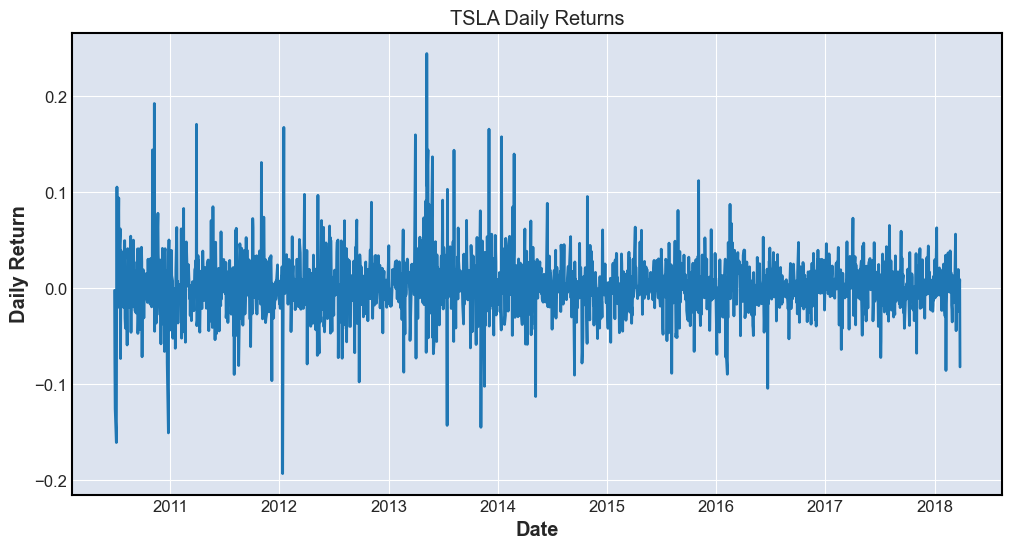

In [140]:
plt.figure(figsize=(12, 6))
plt.plot(df['date'], daily_returns)
plt.title("TSLA Daily Returns")
plt.xlabel('Date')
plt.ylabel("Daily Return")
plt.grid(True)

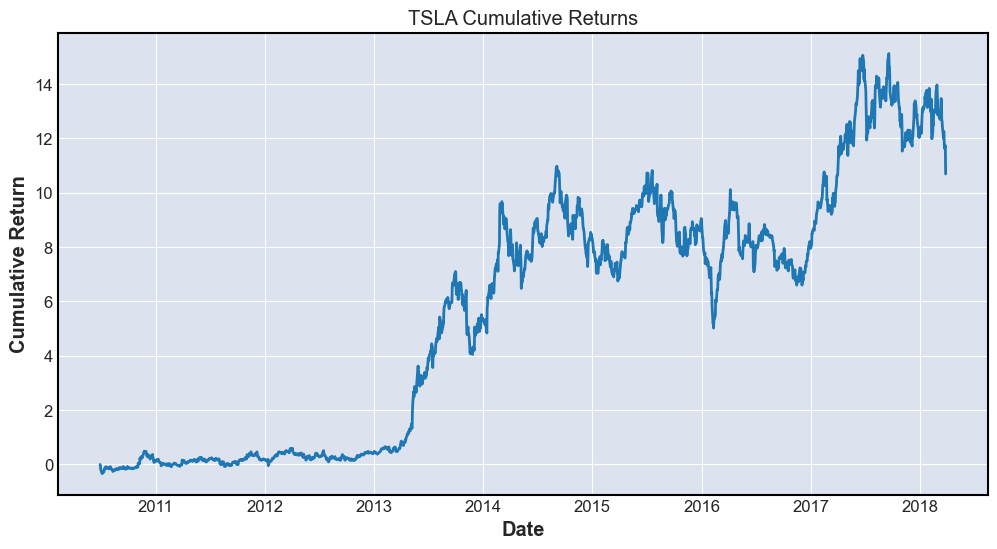

In [144]:
cumulative_returns = (1 + daily_returns).cumprod() - 1
plt.figure(figsize=(12, 6))
plt.plot(df['date'], cumulative_returns)
plt.title("TSLA Cumulative Returns")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.grid(True)

Text(0, 0.5, 'Frequency')

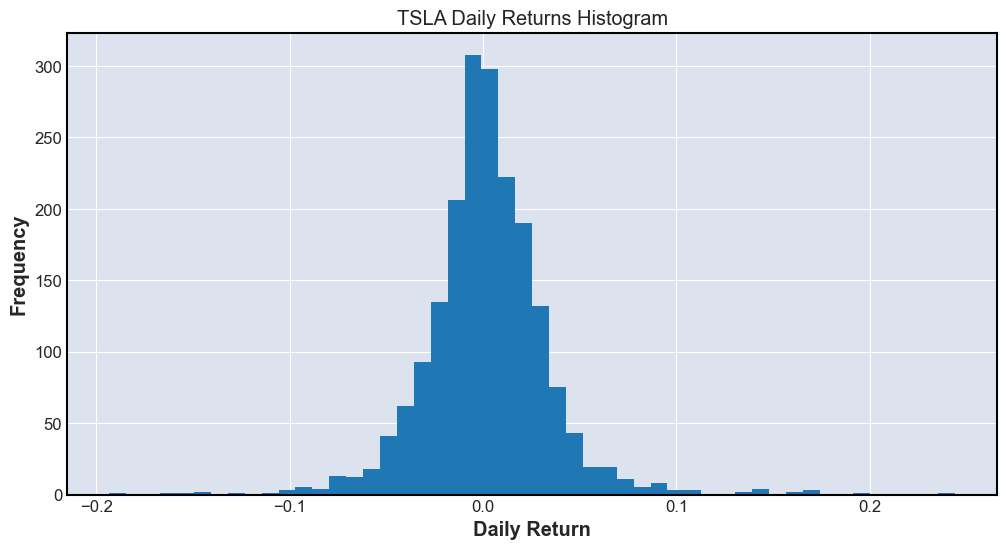

In [146]:
plt.figure(figsize=(12, 6))
daily_returns.hist(bins=50)
plt.title("TSLA Daily Returns Histogram")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

In [147]:
daily_returns.describe()

count    1948.000000
mean        0.001766
std         0.031849
min        -0.193274
25%        -0.013980
50%         0.000828
75%         0.017712
max         0.244029
Name: adj_close, dtype: float64

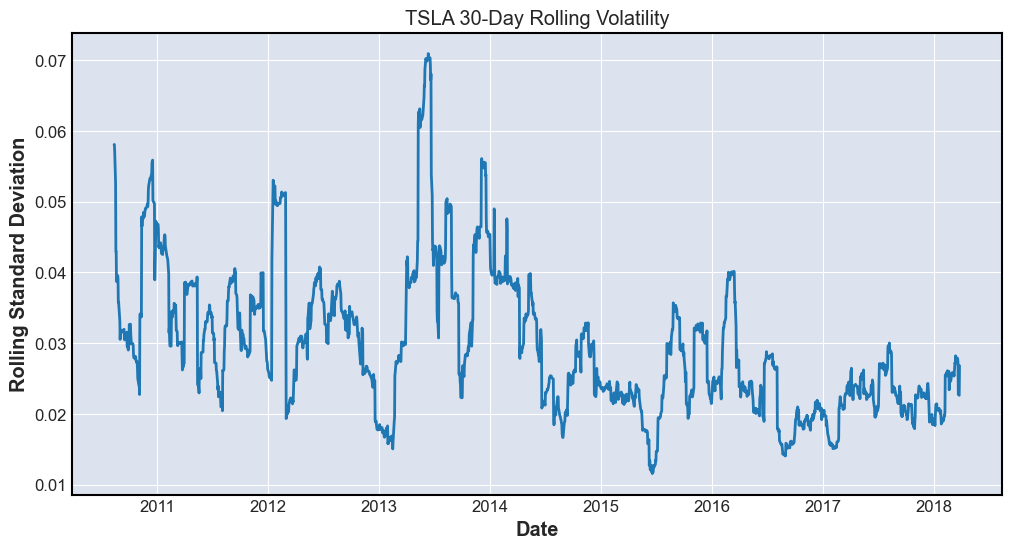

In [152]:
rolling_volatility = daily_returns.rolling(window=30).std()
plt.figure(figsize=(12, 6))
plt.plot(df['date'], rolling_volatility)
plt.title("TSLA 30-Day Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Rolling Standard Deviation")
plt.grid(True)

Text(0.5, 1.0, 'TSLA Daily Returns Q-Q Plot')

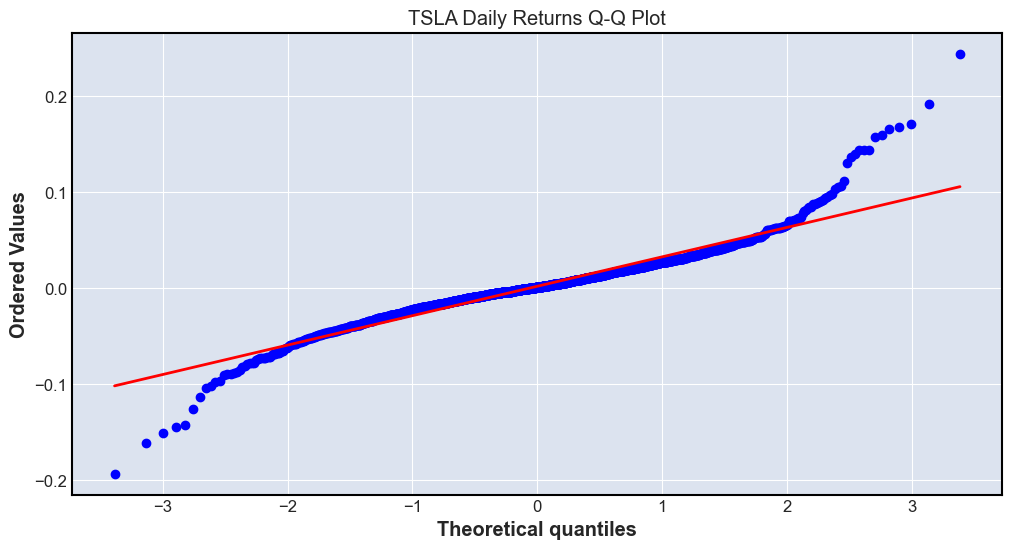

In [156]:
from scipy import stats
returns_clean = daily_returns.dropna()
fig, ax = plt.subplots(figsize=(12,6))
stats.probplot(returns_clean, dist="norm", plot=ax)
ax.set_title("TSLA Daily Returns Q-Q Plot")

In [158]:
df_tsla = nasdaqdatalink.get_table(datatable_code="WIKI/PRICES",
                                   ticker="TSLA",
                                   date={"gte": "2017-12-01", "lte": "2018-03-27"},
                                   qopts={"columns": ["ticker", 'date', 'adj_close']},
                                   api_key=nasdaqdatalink.ApiConfig.api_key)
df_tsla.head()

,ticker,date,adj_close
None,,,
0,TSLA,2018-03-27,279.18
1,TSLA,2018-03-26,304.18
2,TSLA,2018-03-23,301.54
3,TSLA,2018-03-22,309.10
4,TSLA,2018-03-21,316.53


In [161]:
df_aapl = nasdaqdatalink.get_table(datatable_code="WIKI/PRICES",
                                   ticker="AAPL",
                                   date={"gte": "2017-12-01", "lte": "2018-03-27"},
                                   qopts={"columns": ["ticker", 'date', 'adj_close']},
                                   api_key=nasdaqdatalink.ApiConfig.api_key)
df_aapl.head()

,ticker,date,adj_close
None,,,
0,AAPL,2018-03-27,168.340
1,AAPL,2018-03-26,172.770
2,AAPL,2018-03-23,164.940
3,AAPL,2018-03-22,168.845
4,AAPL,2018-03-21,171.270


In [162]:
df_msft = nasdaqdatalink.get_table(datatable_code="WIKI/PRICES",
                                   ticker="MSFT",
                                   date={"gte": "2017-12-01", "lte": "2018-03-27"},
                                   qopts={"columns": ["ticker", 'date', 'adj_close']},
                                   api_key=nasdaqdatalink.ApiConfig.api_key)
df_msft.head()

,ticker,date,adj_close
None,,,
0,MSFT,2018-03-27,89.47
1,MSFT,2018-03-26,93.78
2,MSFT,2018-03-23,87.18
3,MSFT,2018-03-22,89.79
4,MSFT,2018-03-21,92.48


In [164]:
df_multi = pd.concat([df_tsla, df_aapl, df_msft])

In [165]:
df_multi

,ticker,date,adj_close
None,,,
0,TSLA,2018-03-27,279.18
1,TSLA,2018-03-26,304.18
2,TSLA,2018-03-23,301.54
3,TSLA,2018-03-22,309.10
4,TSLA,2018-03-21,316.53
...,...,...,...
74,MSFT,2017-12-07,82.49
75,MSFT,2017-12-06,82.78
76,MSFT,2017-12-05,81.59


In [168]:
df_multi['date'] = pd.to_datetime(df_multi['date'])

In [169]:
df_multi = df_multi.sort_values(["ticker", "date"])

In [170]:
df_multi

,ticker,date,adj_close
None,,,
78,AAPL,2017-12-01,171.050
77,AAPL,2017-12-04,169.800
76,AAPL,2017-12-05,169.640
75,AAPL,2017-12-06,169.010
74,AAPL,2017-12-07,169.452
...,...,...,...
4,TSLA,2018-03-21,316.530
3,TSLA,2018-03-22,309.100
2,TSLA,2018-03-23,301.540


In [172]:
price_table = df_multi.pivot(index='date',
                             columns='ticker',
                             values='adj_close')
price_table

ticker,AAPL,MSFT,TSLA
date,,,
2017-12-01,171.050,84.26,306.53
2017-12-04,169.800,81.08,305.20
2017-12-05,169.640,81.59,303.70
2017-12-06,169.010,82.78,313.26
2017-12-07,169.452,82.49,311.24
...,...,...,...
2018-03-21,171.270,92.48,316.53
2018-03-22,168.845,89.79,309.10
2018-03-23,164.940,87.18,301.54


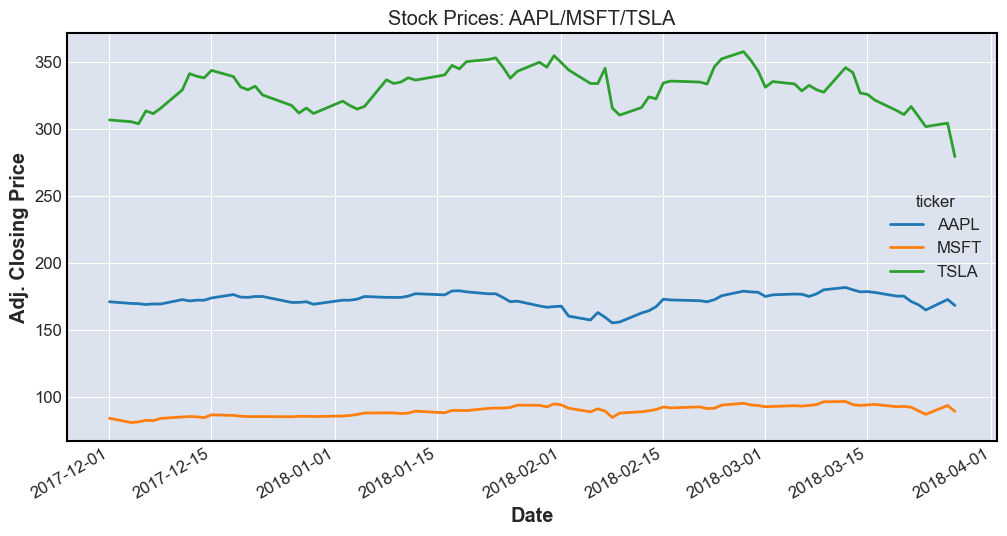

In [173]:
price_table.plot(figsize=(12, 6))
plt.title("Stock Prices: AAPL/MSFT/TSLA")
plt.xlabel('Date')
plt.ylabel('Adj. Closing Price')
plt.grid(True)

In [174]:
multi_returns = price_table.pct_change()

In [176]:
correlation_matrix = multi_returns.corr()
correlation_matrix

ticker,AAPL,MSFT,TSLA
ticker,,,
AAPL,1.000000,0.718067,0.450549
MSFT,0.718067,1.000000,0.499476
TSLA,0.450549,0.499476,1.000000


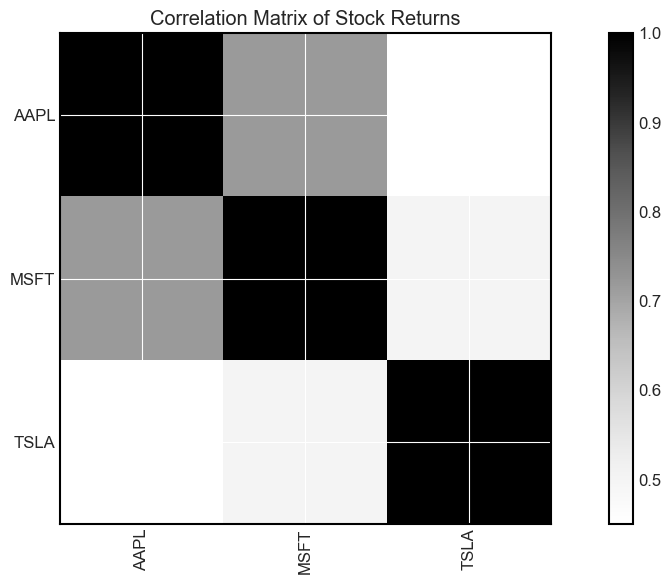

In [177]:
plt.figure(figsize=(12,6))
plt.imshow(correlation_matrix)
plt.colorbar()
plt.xticks(range(len(correlation_matrix.columns)),
           correlation_matrix.columns,
           rotation=90)
plt.yticks(range(len(correlation_matrix.columns)),
           correlation_matrix.columns)
plt.title("Correlation Matrix of Stock Returns")
plt.tight_layout()

In [187]:
tsla_prices = price_table["TSLA"]
tsla_prices

date
2017-12-01    306.53
2017-12-04    305.20
2017-12-05    303.70
2017-12-06    313.26
2017-12-07    311.24
               ...  
2018-03-21    316.53
2018-03-22    309.10
2018-03-23    301.54
2018-03-26    304.18
2018-03-27    279.18
Name: TSLA, Length: 79, dtype: float64

In [188]:
sma_short = tsla_prices.rolling(window=5).mean()

In [189]:
sma_long = tsla_prices.rolling(window=15).mean()

In [191]:
df_sma = pd.DataFrame({"TSLA Price": tsla_prices,
                       "5-Day SMA": sma_short,
                       "15-Day SMA": sma_long})
df_sma

,TSLA Price,5-Day SMA,15-Day SMA
date,,,
2017-12-01,306.53,NaN,NaN
2017-12-04,305.20,NaN,NaN
2017-12-05,303.70,NaN,NaN
2017-12-06,313.26,NaN,NaN
2017-12-07,311.24,307.986,NaN
...,...,...,...
2018-03-21,316.53,317.518,327.849333
2018-03-22,309.10,314.218,326.394000
2018-03-23,301.54,310.256,324.155333


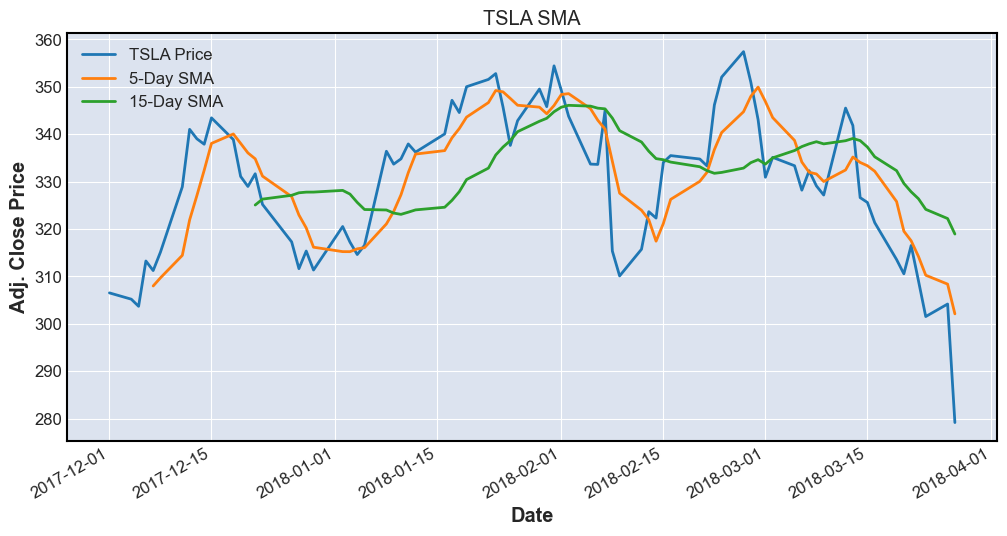

In [193]:
df_sma.plot(figsize=(12, 6))
plt.title("TSLA SMA")
plt.xlabel("Date")
plt.ylabel("Adj. Close Price")
plt.grid(True)

In [194]:
short_ema = tsla_prices.ewm(span=5, adjust=False).mean()

In [195]:
long_ema = tsla_prices.ewm(span=15, adjust=False).mean()

In [201]:
df_ema = pd.DataFrame({"TSLA Price": tsla_prices,
                       "5-Day EMA": short_ema,
                       "15-Day EMA": long_ema})
df_ema

,TSLA Price,5-Day EMA,15-Day EMA
date,,,
2017-12-01,306.53,306.530000,306.530000
2017-12-04,305.20,306.086667,306.363750
2017-12-05,303.70,305.291111,306.030781
2017-12-06,313.26,307.947407,306.934434
2017-12-07,311.24,309.044938,307.472629
...,...,...,...
2018-03-21,316.53,318.127361,326.296939
2018-03-22,309.10,315.118241,324.147322
2018-03-23,301.54,310.592161,321.321407


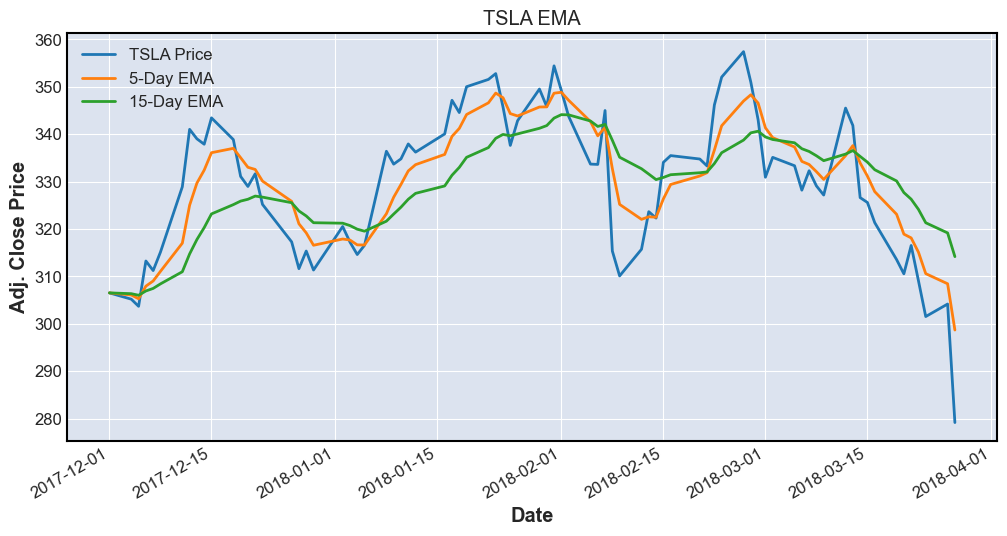

In [202]:
df_ema.plot(figsize=(12, 6))
plt.title("TSLA EMA")
plt.xlabel("Date")
plt.ylabel("Adj. Close Price")
plt.grid(True)